## Data Visualization for Textual Data

This Jupyter Notebook explores different ways to visualize textual data.

We will cover:
1. Word Frequency Visualization
2. Word Clouds
3. N-gram Analysis
4. Distribution of Text Lengths
5. Sentiment Analysis Visualization

Make sure you have a dataset with a column named 'text'.

In [ ]:
# Install required packages (uncomment if needed)
#!pip install pandas numpy matplotlib seaborn wordcloud nltk

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/deniseroth/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/deniseroth/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### **1. Load Dataset**

In [ ]:
df = pd.read_csv("your_dataset.csv")
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
  id                                               text sentiment  \
0  0                                         oh my gosh   Anxiety   
1  1  trouble sleeping, confused mind, restless hear...   Anxiety   
2  2  All wrong, back off dear, forward doubt. Stay ...   Anxiety   
3  3  I've shifted my focus to something else but I'...   Anxiety   
4  4  I'm restless and restless, it's been a month n...   Anxiety   

   condition_binary  
0                 1  
1                 1  
2                 1  
3                 1  
4                 1  


### **2. Word Frequency Visualization**

This section calculates and visualizes the most common words in the dataset.


/var/folders/9h/l4dfxg1x7vzbfrn1dfj65vv40000gn/T/ipykernel_47994/3423029720.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=word_freq_df, palette='viridis')


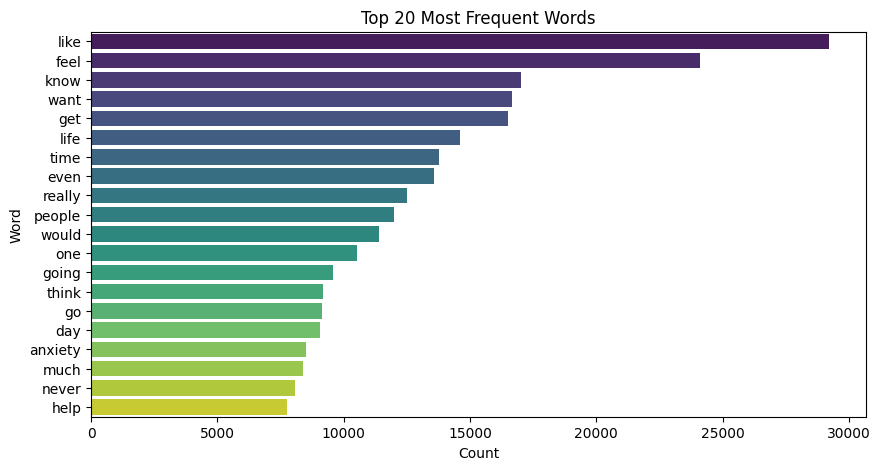

In [5]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    tokens = word_tokenize(str(text).lower())  # Lowercase and tokenize
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]  # Remove stopwords and non-alphabetic tokens
    return tokens

# Apply preprocessing
df['processed_text'] = df['text'].apply(preprocess_text)

# Flatten list of words
total_words = [word for sublist in df['processed_text'] for word in sublist]
word_counts = Counter(total_words)
common_words = word_counts.most_common(20)

# Convert to DataFrame for visualization
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Count'])

# Plot word frequency
plt.figure(figsize=(10,5))
sns.barplot(x='Count', y='Word', data=word_freq_df, palette='viridis')
plt.title("Top 20 Most Frequent Words")
plt.show()

### **3. Word Cloud**

Generate a word cloud to visualize word importance based on frequency.


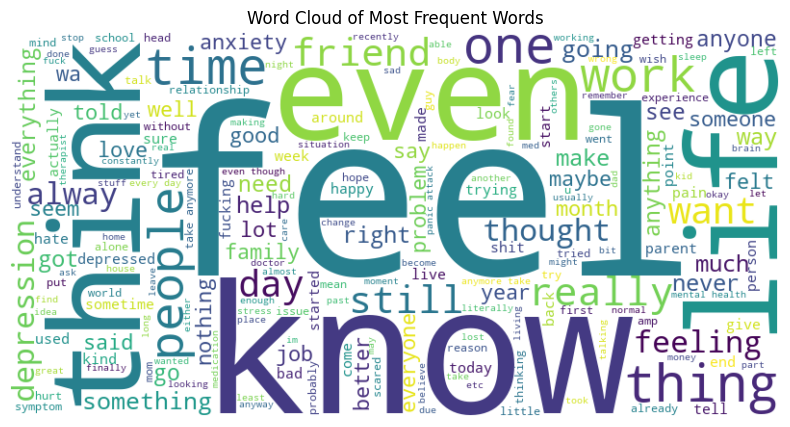

In [6]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(total_words))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Most Frequent Words")
plt.show()

### **4. N-gram Analysis (Bigrams)**

Analyze and visualize common bigrams (two-word phrases).


/var/folders/9h/l4dfxg1x7vzbfrn1dfj65vv40000gn/T/ipykernel_47994/1014323314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Bigram', data=bigram_df, palette='coolwarm')


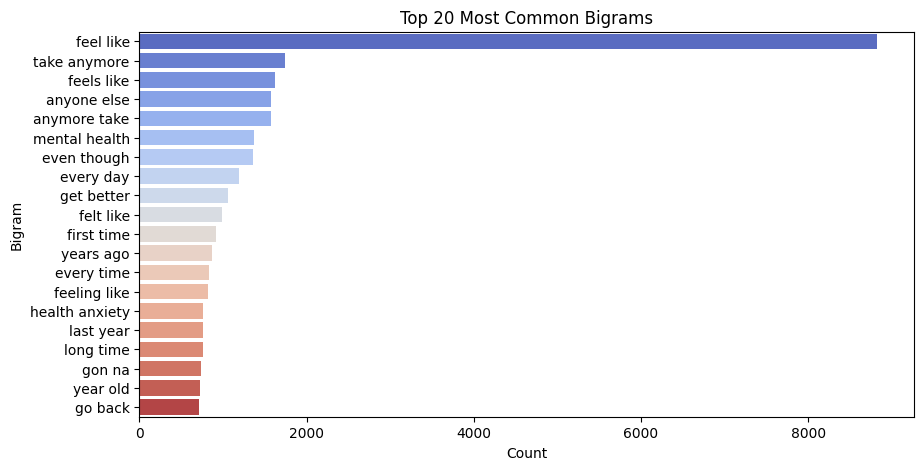

In [7]:
from nltk.util import ngrams

bigrams = list(ngrams(total_words, 2))
bigram_counts = Counter(bigrams).most_common(20)

bigram_df = pd.DataFrame(bigram_counts, columns=['Bigram', 'Count'])
bigram_df['Bigram'] = bigram_df['Bigram'].apply(lambda x: ' '.join(x))

# Plot bigram frequency
plt.figure(figsize=(10,5))
sns.barplot(x='Count', y='Bigram', data=bigram_df, palette='coolwarm')
plt.title("Top 20 Most Common Bigrams")
plt.show()

### **5. Distribution of Text Lengths**

Analyze and visualize the distribution of text lengths in the dataset.


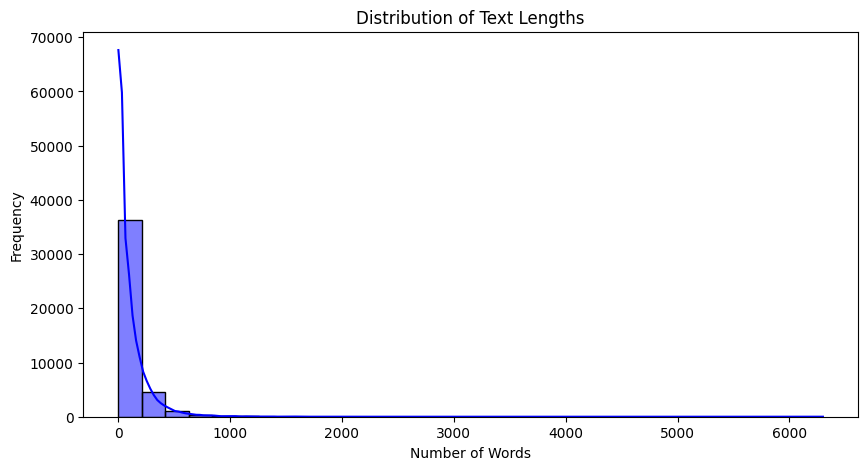

In [8]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
sns.histplot(df['text_length'], bins=30, kde=True, color='blue')
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

### **6. Sentiment Analysis Visualization (Optional)**

If you have sentiment labels, you can visualize their distribution.
Ensure your dataset contains a 'sentiment' column.


/var/folders/9h/l4dfxg1x7vzbfrn1dfj65vv40000gn/T/ipykernel_47994/2454138253.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='muted')


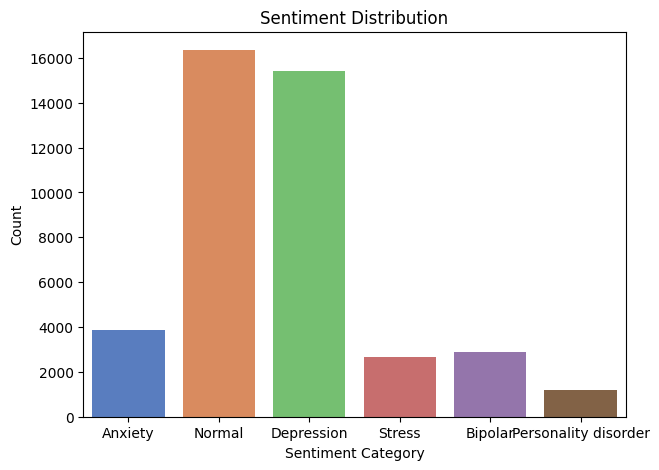

Text Data Visualization Complete!


In [9]:
if 'sentiment' in df.columns:
    plt.figure(figsize=(7,5))
    sns.countplot(x='sentiment', data=df, palette='muted')
    plt.title("Sentiment Distribution")
    plt.xlabel("Sentiment Category")
    plt.ylabel("Count")
    plt.show()

print("Text Data Visualization Complete!")